In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,Optional,List
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage,AIMessage,SystemMessage,ToolMessage
from dotenv import load_dotenv
from langchain_community.tools import TavilySearchResults
from langgraph.checkpoint.memory import InMemorySaver
from uuid import uuid4
import os
load_dotenv()

/var/folders/4r/9cc0tjg51p13g6sf2rd7c2lh0000gn/T/ipykernel_96515/4125755861.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import TavilySearchResults


True

In [14]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
search_tool=TavilySearchResults(max_results=3, tavily_api_key=os.getenv("TAVILY_KEY"))
tools=[search_tool]
llm_with_tools=llm.bind_tools(tools=tools)

In [19]:
class state(TypedDict):
    messages:Annotated[List,add_messages]
    route:str

In [20]:
async def llm_node(state:state)->state:
    res=await llm_with_tools.ainvoke(state["messages"])
    return {"messages":[res]}

async def router(state:state)->str:
    last_msg=state['messages'][-1]
    if last_msg.tool_calls:
        return "tools"
    return "end"


async def routerNode(state:state):
    ROUTER_PROMPT = """You are a routing classifier for Homemakers, a real estate platform in India.
Your only job is to read the user's message and decide which of three categories it belongs to.

Respond with EXACTLY ONE WORD: sql, search, or chat. Nothing else. No punctuation, no explanation.

Use "sql" when the user is asking to find, search, filter, or browse properties based on 
specific criteria that would be stored in a database, such as:
- Location (city, state, district, locality)
- Price or rent budget (under X, between X and Y)
- Property type (apartment, villa, independent house)
- Number of bedrooms/bathrooms, area in sqft
- Availability (for rent, for sale)
- Amenities (gym, parking, swimming pool, etc.)
Examples: "Show me 2BHK flats in Ahmedabad under 50 lakhs", 
"Are there any villas with a pool in Pune", 
"What properties are available for rent in Mumbai"

Use "search" when the user is asking about something requiring current, real-world information 
that is NOT stored in your property database, such as:
- Real estate news, market trends, or price trends
- Government policies, loan rates, tax rules
- General questions about a city or area that aren't about specific listings
Examples: "What are the latest real estate trends in India", 
"Is it a good time to invest in Bangalore real estate", 
"What is RERA"

Use "chat" for everything else, such as:
- Greetings and small talk
- Questions about Homemakers itself (how to list a property, how appointments work)
- General advice that doesn't require a database lookup or current web data
Examples: "Hi", "How do I schedule a visit", "What's the difference between renting and buying"

Respond with only one word: sql, search, or chat."""

    last_user_message = state["messages"][-1].content
    
    messages = [
        SystemMessage(content=ROUTER_PROMPT),
        HumanMessage(content=last_user_message)
    ]
    
    result = await llm.ainvoke(messages)
    decision = result.content.strip().lower()
    
    # Safety fallback in case the LLM outputs something unexpected
    if decision not in ["sql", "search", "chat"]:
        decision = "chat"
    
    return {"route": decision}



In [21]:
async def tool_node(state:state)->state:   #Earlier we would just import Toolnode and pass our tool in it
    tool_calls=state['messages'][-1].tool_calls
    tool_msg=[]
    for tools in tool_calls:
        tool_name=tools["name"]
        tool_arg=tools["args"]
        tool_id=tools["id"]

        if tool_name=="tavily_search_results_json":
            search_results=await search_tool.ainvoke(tool_arg)
            toolmsg=ToolMessage(
            content=str(search_results),
            tool_call_id=tool_id,
            name=tool_name
            )
            tool_msg.append(toolmsg)

    return {"messages":tool_msg}

In [26]:
async def route_decision(state: state):
    route = state.get("route", "chat")
    
    if route == "sql":
        return "sql_node"      # doesn't exist yet, placeholder for now
    elif route == "search":
        return "llm_node"          # goes to your existing Tavily-bound model
    else:
        return "llm_node"          # chat also goes to existing model, just won't trigger tool calls


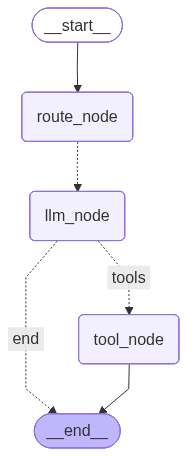

In [30]:
graph=StateGraph(state)
graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)
graph.add_node("route_node",routerNode)
graph.add_edge(START,"route_node")
graph.add_conditional_edges("route_node", route_decision,{
    "llm_node":"llm_node"
})
graph.add_conditional_edges("llm_node",router,{
    "tools":"tool_node",
    "end":END
})
app=graph.compile()
app

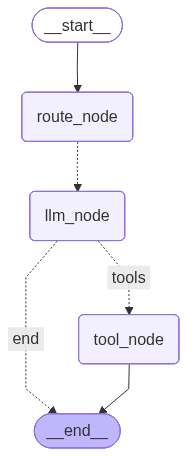

In [31]:
config={"configurable":{"thread_id":"1"}}
memory=InMemorySaver()
app=graph.compile(checkpointer=memory)
app

In [74]:
# res=await app.ainvoke({"messages":HumanMessage(content="What is the current price of silver ETF?")},config=config)
# for msg in res['messages']:
#     print(msg.pretty_print())

In [32]:
res=await app.ainvoke({"messages":HumanMessage(content="Hi there, Tell me the properties located in banglore")},config=config)
for msg in res['messages']:
    print(msg.pretty_print())

KeyError: 'sql_node'

In [25]:
print(res.get('route'))

sql


In [73]:
res=await app.ainvoke({"messages":HumanMessage(content="Hi there whats my name?")},config=config)
for msg in res['messages']:
    print(msg.pretty_print())

================================ Human Message =================================

What is the current price of silver ETF?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (vvwmm3r29)
 Call ID: vvwmm3r29
  Args:
    query: current price of silver ETF
None
================================= Tool Message =================================
Name: tavily_search_results_json

[{'title': 'Silver ETF (SLV) Stock Price Today & Analysis | Buy on Gotrade', 'url': 'https://www.heygotrade.com/en/us-stock/slv', 'content': 'Home\n\nUS Stock\n\nBlog\n\nNews\n\nInsider\n\nMarket Outlook\n\nJoin us\n\nFAQ\n\nLegal central\n\nPress\n\nGlobal\n\nIndonesia\n\n# Silver ETF (SLV) Stock Price Today & Analysis\n\nSLV company logo\n\n### Valuation\n\n### Earnings Per Share\n\n### Income Statement\n\n### Dividend\n\n### Solvency\n\n## About Silver ETF\n\niShares Silver Trust (SLV) is the largest physically backed silver exchange traded f

In [77]:
config={"configurable":{"thread_id":"2"}}
async for event in app.astream_events({"messages":HumanMessage(content="Hi there, its Nisarg")},config=config):
    if event['event']=="on_chat_model_stream":
        print(event['data']["chunk"].content,end="",flush=True)


Hello again Nisarg. How can I assist you today? Do you have any questions or topics you'd like to discuss?